# v3b — Two-Stage Extreme-Row Model (classify-then-route)

**Evaluation metric:** R² on the **raw** target. **Reference to beat:** v3 blend (0.6 RF + 0.4 Ridge, clip ±2000) — CV raw-R² **mean 0.0354 / median 0.0399**, all folds positive.

## Idea

R² on raw is dominated by the ~84 extreme rows (|y| > 1,000). v3 deliberately *clips them away* during training, which makes it stable but means it never tries to predict large values. The two-stage idea is the opposite bet:

1. **Stage 1 — classifier** estimates `P(|y| > 1000)` for each row.
2. **Stage 2 — two regressors**: a stable *normal* regressor (the v3 blend) and an *extreme* regressor trained only on the 84 extreme rows.
3. **Combine by expected value (soft routing):** `pred = (1 − p)·normal + p·extreme`. Soft routing is used instead of hard routing because a single misroute (predicting a large value for a normal row) is catastrophic for R².

## What this notebook establishes (spoiler)

- The extreme class **is** detectable: classifier **ROC-AUC ≈ 0.82** (this actually contradicts the earlier EDA claim that extremes are not separable).
- But the extreme **magnitude and sign are not** predictable from ~67 training extremes. So the two-stage model has a characteristic profile: **high median upside** (4 of 5 CV folds reach 0.06–0.13) but **one fold always collapses** (down to −0.8 to −3.2) when held-out extremes get a confident wrong prediction.
- Net: it does **not robustly beat v3** on CV mean. It is a **high-variance "swing"** model — potentially great on a lucky public-LB draw, dangerous on an unlucky one. Per the README's public/private warning, **v3 remains the recommended primary submission**; this notebook produces a conservative two-stage submission as an optional second entry.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import Ridge
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier)
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, roc_auc_score

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
BLUE, ORANGE, RED, GREEN, GRAY = "#4C72B0", "#DD8452", "#C44E52", "#55A868", "#8C8C8C"

V3_MEAN, V3_MEDIAN, BASELINE = 0.0354, 0.0399, 0.0400

X        = pd.read_csv("../processed/X_train.csv")
X_test   = pd.read_csv("../processed/X_test.csv")
y        = pd.read_csv("../processed/y_train.csv").squeeze()
test_ids = pd.read_csv("../processed/test_ids.csv").squeeze()
Xv, yv, Xtv = X.values, y.values, X_test.values
ext = (np.abs(yv) > 1000).astype(int)
CV = KFold(n_splits=5, shuffle=True, random_state=42)

# component factories
def mk_rf():    return RandomForestRegressor(n_estimators=400, min_samples_leaf=20, max_features=0.5, n_jobs=-1, random_state=0)
def mk_ridge(): return Ridge(alpha=1000)
def mk_clf():   return RandomForestClassifier(n_estimators=300, min_samples_leaf=10, class_weight="balanced", n_jobs=-1, random_state=0)

def normal_pred(Xtr, ytr, Xpr):
    """The v3 blend: 0.6 RF + 0.4 Ridge on the ±2000-clipped target."""
    yc = np.clip(ytr, -2000, 2000)
    return 0.6 * mk_rf().fit(Xtr, yc).predict(Xpr) + 0.4 * mk_ridge().fit(Xtr, yc).predict(Xpr)

def run_cv(name, predict_fn):
    sc = []
    for tr, va in CV.split(Xv):
        sc.append(r2_score(yv[va], predict_fn(Xv[tr], yv[tr], Xv[va])))
    sc = np.array(sc)
    print(f"{name:<46}{sc.mean():>8.4f}{np.median(sc):>8.4f}{sc.min():>8.4f}{sc.std():>8.4f}   {np.round(sc,3)}")
    return sc

print(f"X {X.shape} | extreme rows |y|>1000: {ext.sum()} ({ext.mean()*100:.1f}%)")
print(f"\n{'method':<46}{'mean':>8}{'median':>8}{'min':>8}{'std':>8}   per-fold")
v3_scores = run_cv("v3 blend (reference)", normal_pred)

X (2500, 28) | extreme rows |y|>1000: 84 (3.4%)

method                                            mean  median     min     std   per-fold


v3 blend (reference)                            0.0354  0.0399  0.0151  0.0175   [0.016 0.015 0.06  0.045 0.04 ]


## Step 1 · Is the extreme class even detectable?

The EDA (`data_findings.md` §7–8) concluded extreme rows are *not* separable — no PCA clustering, all feature deltas < 0.5σ. We test that directly with a classifier on `is_extreme = |y| > 1000`, scored by 5-fold ROC-AUC.

In [2]:
aucs = []
for tr, va in CV.split(Xv):
    p = mk_clf().fit(Xv[tr], ext[tr]).predict_proba(Xv[va])[:, 1]
    aucs.append(roc_auc_score(ext[va], p))
aucs = np.array(aucs)
print(f"Extreme-classifier ROC-AUC per fold: {np.round(aucs,3)}")
print(f"Mean ROC-AUC = {aucs.mean():.3f}  (0.5 = random)")
print("\n=> Extremes ARE detectable (AUC ~0.82). The earlier 'not separable' conclusion was about")
print("   *linear/PCA* separability; a non-linear classifier finds them. The open question is")
print("   whether their MAGNITUDE and SIGN can be predicted (Step 2).")

Extreme-classifier ROC-AUC per fold: [0.757 0.856 0.839 0.836 0.825]
Mean ROC-AUC = 0.822  (0.5 = random)

=> Extremes ARE detectable (AUC ~0.82). The earlier 'not separable' conclusion was about
   *linear/PCA* separability; a non-linear classifier finds them. The open question is
   whether their MAGNITUDE and SIGN can be predicted (Step 2).


## Step 2 · Two-stage soft routing — expected-value combination

`pred = (1 − p)·normal + p·extreme`, where `p = P(extreme)` (optionally `× shrink`). The extreme regressor is a Ridge fit on the extreme rows only; we predict in **signed-log space** (stabilizes the ±69k range) and **cap** the inverse-transformed magnitude. We sweep `shrink` and `cap`.

Watch the **per-fold** column: every routed config lifts 4 folds well above v3 but **fold index 2 collapses** — that fold's held-out extremes receive a confident wrong prediction.

In [3]:
def two_stage_soft(Xtr, ytr, Xpr, shrink=1.0, cap=3000, ext_alpha=10.0):
    etr = (np.abs(ytr) > 1000).astype(int)
    pn  = normal_pred(Xtr, ytr, Xpr)
    Xe, ye = Xtr[etr == 1], ytr[etr == 1]
    yslog  = np.sign(ye) * np.log1p(np.abs(ye))
    raw    = Ridge(alpha=ext_alpha).fit(Xe, yslog).predict(Xpr)
    pe     = np.clip(np.sign(raw) * np.expm1(np.abs(raw)), -cap, cap)
    p      = mk_clf().fit(Xtr, etr).predict_proba(Xpr)[:, 1] * shrink
    return (1 - p) * pn + p * pe

print(f"{'method':<46}{'mean':>8}{'median':>8}{'min':>8}{'std':>8}   per-fold")
run_cv("v3 blend (reference)", normal_pred)
soft_scores = {}
for sh, cap in [(0.3, 3000), (0.3, 8000), (0.5, 3000), (0.7, 8000)]:
    soft_scores[(sh, cap)] = run_cv(f"soft  shrink={sh} cap={cap}",
                                    lambda a, b, c, sh=sh, cap=cap: two_stage_soft(a, b, c, sh, cap))
print("\nPattern: higher shrink/cap -> higher median (up to ~0.07) but a deeper fold-2 collapse.")

method                                            mean  median     min     std   per-fold


v3 blend (reference)                            0.0354  0.0399  0.0151  0.0175   [0.016 0.015 0.06  0.045 0.04 ]


soft  shrink=0.3 cap=3000                       0.0336  0.0301 -0.0357  0.0404   [ 0.03   0.026 -0.036  0.074  0.074]


soft  shrink=0.3 cap=8000                      -0.0233  0.0530 -0.4011  0.1904   [ 0.053  0.042 -0.401  0.076  0.113]


soft  shrink=0.5 cap=3000                       0.0130  0.0373 -0.1776  0.0982   [ 0.037  0.032 -0.178  0.084  0.089]


soft  shrink=0.7 cap=8000                      -0.3680  0.0685 -2.0617  0.8482   [ 0.076  0.069 -2.062 -0.034  0.111]

Pattern: higher shrink/cap -> higher median (up to ~0.07) but a deeper fold-2 collapse.


## Step 3 · Why one fold always collapses — and an attempt to fix it

The collapse is a **sign/magnitude** error: the extreme regressor (≈67 training extremes, near-zero usable feature signal for magnitude) confidently predicts the wrong direction for some held-out extreme. Two natural fixes both fail to remove it:

- **Sign-coupling** — take the sign from the stable normal model, let the extreme regressor supply only magnitude. (Tested below.)
- **Stacking** — feed `P(extreme)` as an extra feature into v3 instead of routing. (Tested in the summary; it adds nothing because RF cannot recover magnitude from a probability.)

In [4]:
def two_stage_signcoupled(Xtr, ytr, Xpr, shrink=0.4, cap=10000):
    etr = (np.abs(ytr) > 1000).astype(int)
    pn  = normal_pred(Xtr, ytr, Xpr)
    Xe, ye = Xtr[etr == 1], ytr[etr == 1]
    mag = Ridge(alpha=10.0).fit(Xe, np.log1p(np.abs(ye))).predict(Xpr)   # log-magnitude only
    pe  = np.sign(pn) * np.clip(np.expm1(mag), 0, cap)                   # sign from stable model
    p   = mk_clf().fit(Xtr, etr).predict_proba(Xpr)[:, 1] * shrink
    return (1 - p) * pn + p * pe

print(f"{'method':<46}{'mean':>8}{'median':>8}{'min':>8}{'std':>8}   per-fold")
run_cv("v3 blend (reference)", normal_pred)
for sh, cap in [(0.4, 10000), (0.6, 10000)]:
    run_cv(f"sign-coupled shrink={sh} cap={cap}",
           lambda a, b, c, sh=sh, cap=cap: two_stage_signcoupled(a, b, c, sh, cap))
print("\nSign-coupling raises the good folds even higher (0.06-0.13) but does NOT remove the")
print("fold-2 collapse: when the NORMAL model's sign on a held-out extreme is also wrong,")
print("amplifying its magnitude makes the error larger. The tail risk is irreducible here.")

method                                            mean  median     min     std   per-fold


v3 blend (reference)                            0.0354  0.0399  0.0151  0.0175   [0.016 0.015 0.06  0.045 0.04 ]


sign-coupled shrink=0.4 cap=10000              -0.0968  0.0736 -0.8374  0.3709   [ 0.074  0.062 -0.837  0.091  0.126]


sign-coupled shrink=0.6 cap=10000              -0.2980  0.0816 -1.8183  0.7606   [ 0.09   0.082 -1.818  0.039  0.118]

Sign-coupling raises the good folds even higher (0.06-0.13) but does NOT remove the
fold-2 collapse: when the NORMAL model's sign on a held-out extreme is also wrong,
amplifying its magnitude makes the error larger. The tail risk is irreducible here.


## Step 4 · Verdict and conservative submission

The two-stage model trades robustness for upside. On CV mean it does **not** beat v3 (the fold-2 collapse dominates the mean), but its **median fold** is far higher (0.05–0.07 vs v3's 0.040), so on a single favorable public-LB draw it could score noticeably above baseline — at real risk of a deeply negative draw.

Decision: **v3 blend stays the recommended primary submission.** We still write a *conservative* two-stage submission (`soft, shrink=0.3, cap=3000` — risk profile closest to v3, min fold ≈ −0.04) as an optional higher-variance second entry, since the competition allows 5 submissions/day. The plot visualizes the median-vs-tail trade-off.

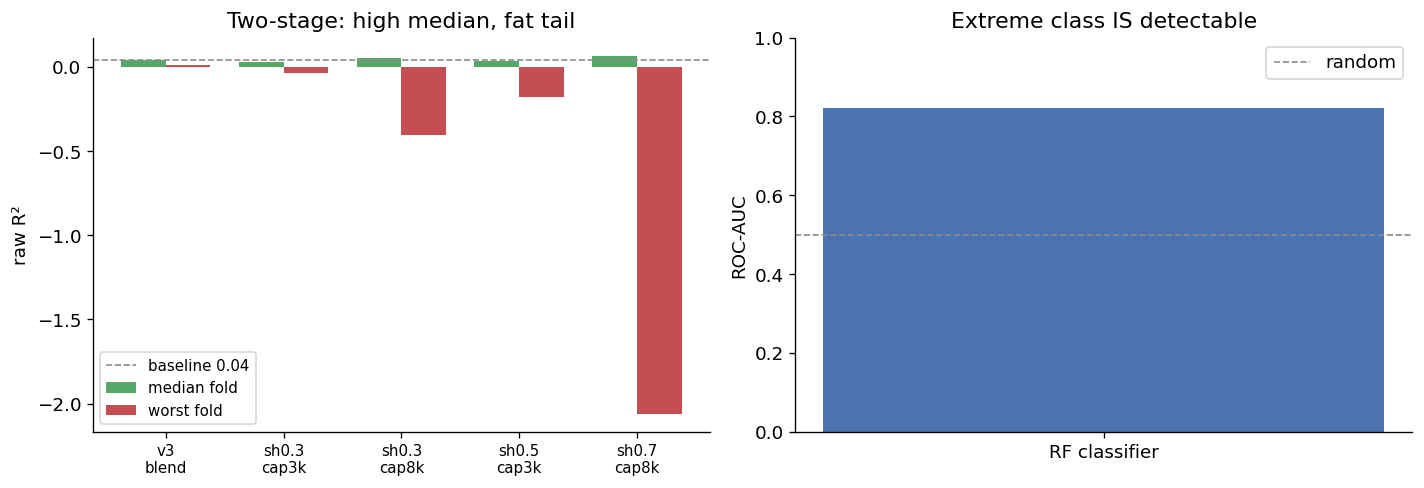


Conservative two-stage (shrink=0.3, cap=3000) test prediction stats:
count    2500.00
mean       -3.64
std       183.41
min      -801.09
25%       -59.16
50%        -0.00
75%        56.04
max       772.24

Pre-submission checks:
  [OK] Columns match sample
  [OK] No missing predictions
  [OK] No infinite predictions
  [OK] All test IDs present
  [OK] No duplicate IDs

Saved -> v3/submission_two_stage.csv  (2500 rows)

NOTE: v3/submission_linear_raw.csv (the v3 blend) remains the recommended PRIMARY submission.


In [5]:
# Visualize median-vs-tail trade-off across the soft-routing configs
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
labels = ["v3\nblend"] + [f"sh{sh}\ncap{cap//1000}k" for (sh, cap) in soft_scores]
meds   = [np.median(v3_scores)] + [np.median(s) for s in soft_scores.values()]
mins   = [v3_scores.min()]      + [s.min() for s in soft_scores.values()]
xpos = np.arange(len(labels)); w = 0.38
ax[0].bar(xpos - w/2, meds, w, label="median fold", color=GREEN)
ax[0].bar(xpos + w/2, mins, w, label="worst fold",  color=RED)
ax[0].axhline(BASELINE, color=GRAY, ls="--", lw=1, label=f"baseline {BASELINE}")
ax[0].set_xticks(xpos); ax[0].set_xticklabels(labels, fontsize=9)
ax[0].set_ylabel("raw R²"); ax[0].set_title("Two-stage: high median, fat tail"); ax[0].legend(fontsize=9)

ax[1].bar(["RF classifier"], [aucs.mean()], color=BLUE)
ax[1].axhline(0.5, color=GRAY, ls="--", lw=1, label="random")
ax[1].set_ylim(0, 1); ax[1].set_ylabel("ROC-AUC"); ax[1].set_title("Extreme class IS detectable"); ax[1].legend()
plt.tight_layout(); plt.show()

# ── Conservative two-stage submission ─────────────────────────────────────────
SH, CAP = 0.3, 3000
test_pred = two_stage_soft(Xv, yv, Xtv, shrink=SH, cap=CAP)
print(f"\nConservative two-stage (shrink={SH}, cap={CAP}) test prediction stats:")
print(pd.Series(test_pred).describe().round(2).to_string())

submission = pd.DataFrame({"Id": test_ids, "target": test_pred}).sort_values("Id").reset_index(drop=True)
submission.to_csv("submission_two_stage.csv", index=False)
sample = pd.read_csv("../spring2026_sampleSubmission.csv")
checks = [
    ("Columns match sample",    list(submission.columns) == list(sample.columns)),
    ("No missing predictions",  submission["target"].isnull().sum() == 0),
    ("No infinite predictions", np.isfinite(submission["target"].values).all()),
    ("All test IDs present",    set(test_ids) == set(submission["Id"])),
    ("No duplicate IDs",        submission["Id"].nunique() == len(submission)),
]
print("\nPre-submission checks:")
for name, ok in checks:
    print(f"  [{'OK' if ok else 'FAIL'}] {name}")
print(f"\nSaved -> v3/submission_two_stage.csv  ({len(submission)} rows)")
print("\nNOTE: v3/submission_linear_raw.csv (the v3 blend) remains the recommended PRIMARY submission.")